# 1. 机器学习综述及示例


## 1.1. 介绍

机器学习是人工智能的一个重要分支，它使计算机能够从数据中学习并做出预测或决策，而无需明确编程。本实验将介绍机器学习的基本概念、分类和应用。


## 1.2. 知识点

* 机器学习基本概念
* 监督学习、无监督学习和强化学习
* 机器学习应用示例
* Python机器学习库介绍


## 1.3. 机器学习基本概念

机器学习是让计算机从数据中自动学习模式的技术。根据学习方式，机器学习可以分为三大类：

### 1.3.1. 监督学习（Supervised Learning）
- **定义**：使用标记的训练数据来学习输入和输出之间的映射关系
- **目标**：预测新数据的输出
- **典型算法**：线性回归、逻辑回归、决策树、支持向量机、神经网络
- **应用场景**：房价预测、邮件分类、图像识别

### 1.3.2. 无监督学习（Unsupervised Learning）
- **定义**：从无标记的数据中发现隐藏的模式和结构
- **目标**：数据探索、降维、聚类
- **典型算法**：K-means聚类、主成分分析(PCA)、关联规则
- **应用场景**：客户细分、异常检测、数据压缩

### 1.3.3. 强化学习（Reinforcement Learning）
- **定义**：通过与环境交互，通过奖励和惩罚机制学习最优策略
- **目标**：学习在特定环境中的最优行为
- **典型算法**：Q-learning、SARSA、深度Q网络(DQN)
- **应用场景**：游戏AI、机器人控制、自动驾驶


## 1.4. Python机器学习库介绍

Python是机器学习领域最流行的编程语言之一，拥有丰富的机器学习库：

### 1.4.1. 核心库
- **NumPy**：数值计算基础库
- **Pandas**：数据处理和分析
- **Matplotlib/Seaborn**：数据可视化
- **Scikit-learn**：机器学习算法库

### 1.4.2. 深度学习库
- **TensorFlow**：Google开发的深度学习框架
- **PyTorch**：Facebook开发的深度学习框架
- **Keras**：高级神经网络API

### 1.4.3. 其他重要库
- **SciPy**：科学计算
- **Statsmodels**：统计建模
- **XGBoost/LightGBM**：梯度提升算法


In [1]:
# 导入必要的库
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, mean_squared_error

import warnings
warnings.filterwarnings('ignore')

# 设置中文字体（使用 macOS 自带字体）
plt.rcParams['font.sans-serif'] = ['PingFang HK', 'Songti SC', 'Arial Unicode MS', 'Heiti TC']  # 优先使用宋体-简
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

# plt.style.use('ggplot')  # 设置图表风格
pd.set_option('display.max_columns', 50)  # 显示最多50列

print("机器学习库导入成功！")

机器学习库导入成功！


## 1.5. 监督学习示例：线性回归

让我们使用加州房价数据集来演示监督学习：


In [2]:
# 加载加州房价数据集
housing = datasets.fetch_california_housing()
X = housing.data
y = housing.target

print(f"数据集形状: {X.shape}")
print(f"特征名称: {housing.feature_names}")
print(f"目标变量范围: {y.min():.2f} - {y.max():.2f}")

# 创建DataFrame便于查看
df = pd.DataFrame(X, columns=housing.feature_names)
df['房价'] = y
print("\n数据集前5行:")
print(df.head())

# 特征说明
print("\n特征说明:")
feature_descriptions = {
    'MedInc': '收入中位数',
    'HouseAge': '房屋年龄',
    'AveRooms': '平均房间数',
    'AveBedrms': '平均卧室数',
    'Population': '人口数量',
    'AveOccup': '平均居住人数',
    'Latitude': '纬度',
    'Longitude': '经度'
}

for feature, description in feature_descriptions.items():
    print(f"{feature}: {description}")


数据集形状: (20640, 8)
特征名称: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
目标变量范围: 0.15 - 5.00

数据集前5行:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude     房价  
0    -122.23  4.526  
1    -122.22  3.585  
2    -122.24  3.521  
3    -122.25  3.413  
4    -122.25  3.422  

特征说明:
MedInc: 收入中位数
HouseAge: 房屋年龄
AveRooms: 平均房间数
AveBedrms: 平均卧室数
Population: 人口数量
AveOccup: 平均居住人数
Latitude: 纬度
Longitude: 经度


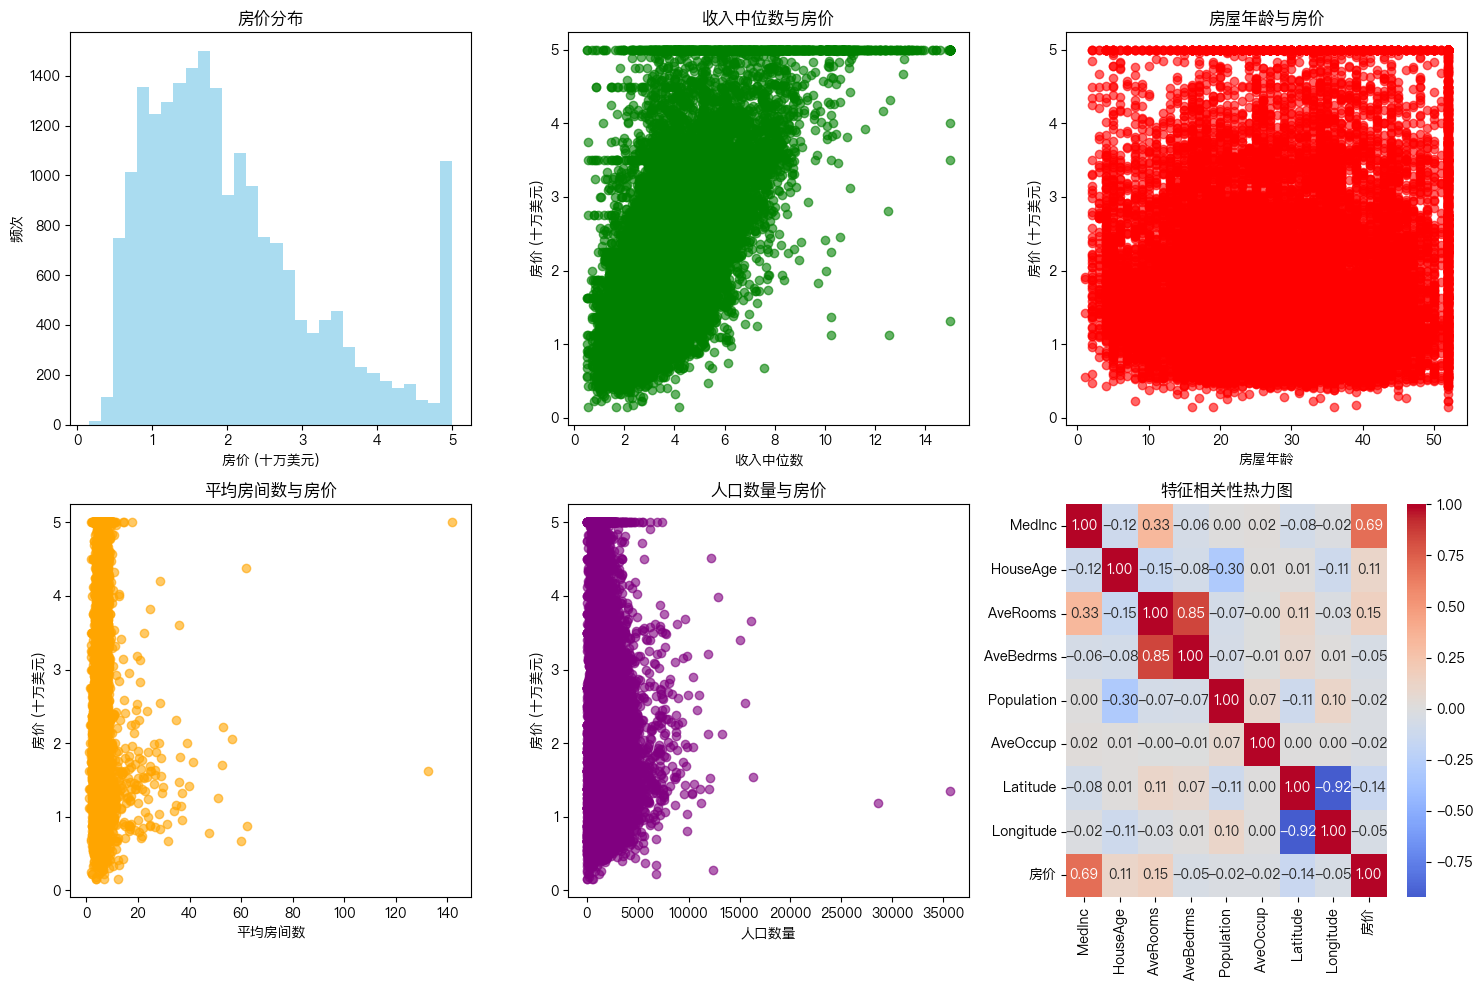

In [3]:
# 数据可视化
plt.figure(figsize=(15, 10))

# 房价分布
plt.subplot(2, 3, 1)
plt.hist(y, bins=30, alpha=0.7, color='skyblue')
plt.title('房价分布')
plt.xlabel('房价 (十万美元)')
plt.ylabel('频次')

# 收入中位数与房价的关系
plt.subplot(2, 3, 2)
plt.scatter(X[:, 0], y, alpha=0.6, color='green')
plt.title('收入中位数与房价')
plt.xlabel('收入中位数')
plt.ylabel('房价 (十万美元)')

# 房屋年龄与房价的关系
plt.subplot(2, 3, 3)
plt.scatter(X[:, 1], y, alpha=0.6, color='red')
plt.title('房屋年龄与房价')
plt.xlabel('房屋年龄')
plt.ylabel('房价 (十万美元)')

# 平均房间数与房价的关系
plt.subplot(2, 3, 4)
plt.scatter(X[:, 2], y, alpha=0.6, color='orange')
plt.title('平均房间数与房价')
plt.xlabel('平均房间数')
plt.ylabel('房价 (十万美元)')

# 人口数量与房价的关系
plt.subplot(2, 3, 5)
plt.scatter(X[:, 4], y, alpha=0.6, color='purple')
plt.title('人口数量与房价')
plt.xlabel('人口数量')
plt.ylabel('房价 (十万美元)')

# 特征相关性热力图
plt.subplot(2, 3, 6)
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('特征相关性热力图')

plt.tight_layout()
plt.show()


均方误差 (MSE): 0.56
决定系数 (R²): 0.576

特征重要性（按系数绝对值排序）:
           特征        系数
3   AveBedrms  0.783145
0      MedInc  0.448675
7   Longitude -0.433708
6    Latitude -0.419792
2    AveRooms -0.123323
1    HouseAge  0.009724
5    AveOccup -0.003526
4  Population -0.000002


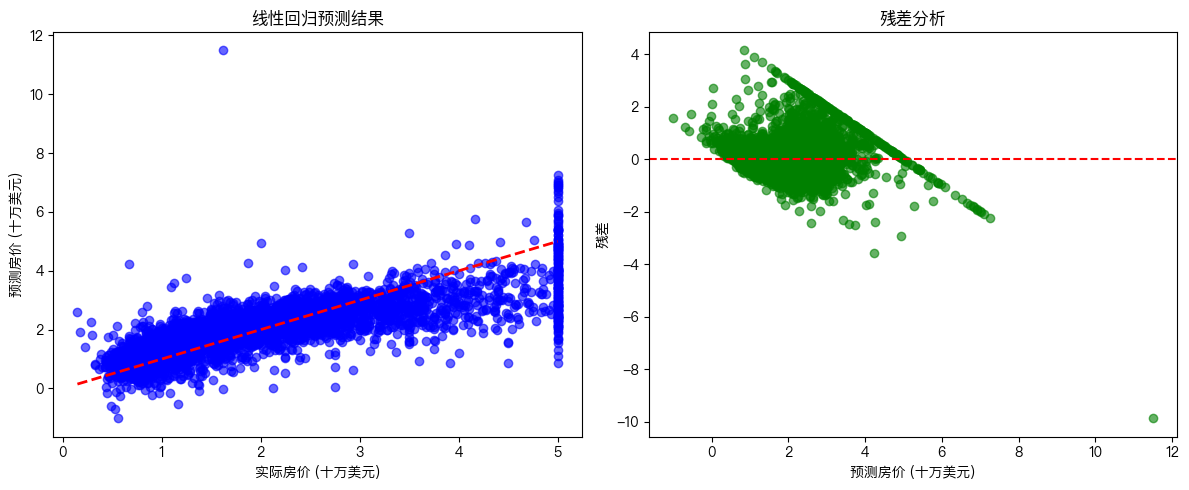

In [4]:
# 训练线性回归模型
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 创建并训练模型
model = LinearRegression()
model.fit(X_train, y_train)

# 预测
y_pred = model.predict(X_test)

# 评估模型
mse = mean_squared_error(y_test, y_pred)
r2 = model.score(X_test, y_test)

print(f"均方误差 (MSE): {mse:.2f}")
print(f"决定系数 (R²): {r2:.3f}")

# 特征重要性分析
feature_importance = pd.DataFrame({
    '特征': housing.feature_names,
    '系数': model.coef_
}).sort_values('系数', key=abs, ascending=False)

print("\n特征重要性（按系数绝对值排序）:")
print(feature_importance)

# 可视化预测结果
plt.figure(figsize=(12, 5))

# 预测vs实际
plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred, alpha=0.6, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('实际房价 (十万美元)')
plt.ylabel('预测房价 (十万美元)')
plt.title('线性回归预测结果')

# 残差分析
plt.subplot(1, 2, 2)
residuals = y_test - y_pred
plt.scatter(y_pred, residuals, alpha=0.6, color='green')
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('预测房价 (十万美元)')
plt.ylabel('残差')
plt.title('残差分析')

plt.tight_layout()
plt.show()


## 1.6. 无监督学习示例：K-means聚类

现在让我们使用鸢尾花数据集来演示无监督学习中的聚类算法：


鸢尾花数据集形状: (150, 4)
特征名称: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
类别名称: ['setosa' 'versicolor' 'virginica']


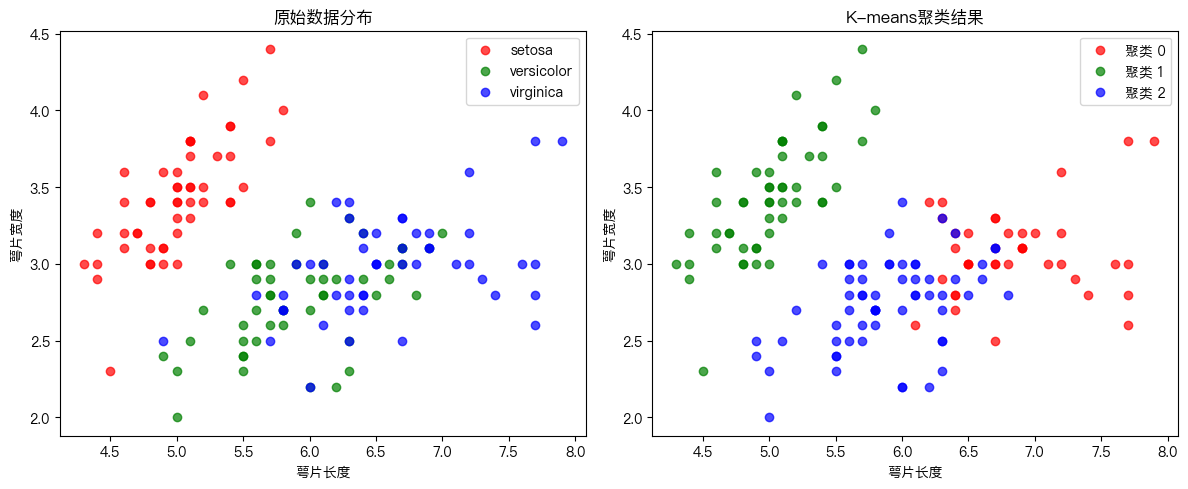

In [5]:
# 加载鸢尾花数据集
iris = datasets.load_iris()
X_iris = iris.data
y_iris = iris.target

print(f"鸢尾花数据集形状: {X_iris.shape}")
print(f"特征名称: {iris.feature_names}")
print(f"类别名称: {iris.target_names}")

# 可视化原始数据
plt.figure(figsize=(12, 5))

# 原始数据分布
plt.subplot(1, 2, 1)
colors = ['red', 'green', 'blue']
for i in range(3):
    plt.scatter(X_iris[y_iris == i, 0], X_iris[y_iris == i, 1], 
               c=colors[i], label=iris.target_names[i], alpha=0.7)
plt.xlabel('萼片长度')
plt.ylabel('萼片宽度')
plt.title('原始数据分布')
plt.legend()

# 使用K-means聚类
kmeans = KMeans(n_clusters=3, random_state=42)
y_kmeans = kmeans.fit_predict(X_iris)

# 聚类结果
plt.subplot(1, 2, 2)
plt.scatter(X_iris[y_kmeans == 0, 0], X_iris[y_kmeans == 0, 1], 
           c='red', label='聚类 0', alpha=0.7)
plt.scatter(X_iris[y_kmeans == 1, 0], X_iris[y_kmeans == 1, 1], 
           c='green', label='聚类 1', alpha=0.7)
plt.scatter(X_iris[y_kmeans == 2, 0], X_iris[y_kmeans == 2, 1], 
           c='blue', label='聚类 2', alpha=0.7)
plt.xlabel('萼片长度')
plt.ylabel('萼片宽度')
plt.title('K-means聚类结果')
plt.legend()

plt.tight_layout()
plt.show()


## 1.7. 机器学习应用领域

机器学习在各个领域都有广泛的应用：

### 1.7.1. 计算机视觉
- **图像分类**：识别图片中的物体
- **目标检测**：在图像中定位和识别多个物体
- **人脸识别**：身份验证和安全系统
- **医学影像**：辅助医生诊断疾病

### 1.7.2. 自然语言处理
- **机器翻译**：Google翻译、百度翻译
- **情感分析**：分析文本的情感倾向
- **聊天机器人**：智能客服系统
- **文本摘要**：自动生成文章摘要

### 1.7.3. 推荐系统
- **电商推荐**：Amazon、淘宝的商品推荐
- **内容推荐**：Netflix、YouTube的内容推荐
- **社交网络**：Facebook、微信的朋友推荐

### 1.7.4. 金融科技
- **风险评估**：贷款审批、保险定价
- **算法交易**：高频交易、量化投资
- **反欺诈**：信用卡欺诈检测
- **智能投顾**：个性化投资建议


## 1.8. 总结

通过本实验，我们学习了：

1. **机器学习基本概念**：监督学习、无监督学习和强化学习的区别
2. **Python机器学习库**：NumPy、Pandas、Scikit-learn等核心库的使用
3. **监督学习示例**：使用线性回归预测加州房价，分析了收入中位数、房屋年龄等关键因素
4. **无监督学习示例**：使用K-means进行鸢尾花数据聚类
5. **应用领域**：机器学习在计算机视觉、自然语言处理、推荐系统等领域的应用

### 加州房价数据集特点：
- **数据规模**：20,640个样本，8个特征
- **关键特征**：收入中位数、房屋年龄、平均房间数等
- **目标变量**：房价中位数（十万美元）
- **地理信息**：包含纬度和经度，体现地理位置对房价的影响

机器学习是一个快速发展的领域，掌握这些基础知识将为后续的深入学习打下坚实的基础。在接下来的实验中，我们将深入学习各种机器学习算法的具体实现和应用。
